In [8]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family'      : 'sans-serif',
    'axes.facecolor'   : '#0f172a',  # Slate Gray 900
    'figure.facecolor' : '#020617',  # Deep Slate 950
    'axes.edgecolor'   : '#334155',  # Slate border
    'axes.labelcolor'  : '#94a3b8',  # Text abu-abu halus
    'xtick.color'      : '#10b981',  # Sumbu X Hijau Emerald
    'ytick.color'      : '#10b981',  # Sumbu Y Hijau Emerald
    'text.color'       : '#f8fafc',  # Teks putih bersih
    'grid.color'       : '#1e293b',  # Kisi tipis
    'grid.linestyle'   : '-',
    'grid.alpha'       : 0.5
})

WARNA_EMISI  = '#34d399'  # Hijau Mint/Emerald untuk kurva karbon
WARNA_AREA   = '#10b981'  # Hijau Emerald untuk area integral
WARNA_PUNCAK = '#f59e0b'  # Amber/Kuning untuk menandai beban emisi maksimum
WARNA_ERROR  = '#38bdf8'  # Cyan/Biru Muda untuk analisis error

print("[INFO] Library berhasil dimuat. Tema visual 'Eco-Analytics' aktif.")


[INFO] Library berhasil dimuat. Tema visual 'Eco-Analytics' aktif.


In [9]:
# ==============================================================
# [A] DESKRIPSI MASALAH DAN SATUAN
# ==============================================================
print("\n" + "="*75)
print(" BAGIAN A — DESKRIPSI MASALAH DAN SATUAN AMATAN")
print("="*75)
print("• Konteks Sistem  : Akumulasi emisi gas rumah kaca (CO2) lalu lintas urban.")
print("• Variabel Bebas  : Waktu (t) dalam satuan [jam], rentang 0 s.d 8 jam.")
print("• Variabel Terikat: Laju emisi kendaraan sesaat E(t) dalam satuan [kg/jam].")
print("• Target Output   : Total massa akumulasi emisi karbon dalam satuan [kg].")


 BAGIAN A — DESKRIPSI MASALAH DAN SATUAN AMATAN
• Konteks Sistem  : Akumulasi emisi gas rumah kaca (CO2) lalu lintas urban.
• Variabel Bebas  : Waktu (t) dalam satuan [jam], rentang 0 s.d 8 jam.
• Variabel Terikat: Laju emisi kendaraan sesaat E(t) dalam satuan [kg/jam].
• Target Output   : Total massa akumulasi emisi karbon dalam satuan [kg].


In [10]:
# ==============================================================
# [B] MODEL MATEMATIS
# ==============================================================
print("\n" + "="*75)
print(" BAGIAN B — FORMULASI MODEL MATEMATIS (FUNGSI KUADRATIK)")
print("="*75)
print("• Model Laju Emisi Tunggal Cekung ke Bawah:")
print("  E(t) = 5*sin(1.5*t) + 3*sin(3*t) + 12")
print("• Formulasi Integral Tentu untuk Akumulasi Massa Emisi:")
print("  S = Integral dari t=0 hingga t=8 untuk fungsi (5*sin(1.5*t) + 3*sin(3*t) + 12) dt")

# Deklarasi variabel global batas interval
batas_bawah, batas_atas = 0, 8


 BAGIAN B — FORMULASI MODEL MATEMATIS (FUNGSI KUADRATIK)
• Model Laju Emisi Tunggal Cekung ke Bawah:
  E(t) = 5*sin(1.5*t) + 3*sin(3*t) + 12
• Formulasi Integral Tentu untuk Akumulasi Massa Emisi:
  S = Integral dari t=0 hingga t=8 untuk fungsi (5*sin(1.5*t) + 3*sin(3*t) + 12) dt


In [11]:
print("\n" + "="*75)
print(" EVALUASI INTEGRAL SECARA SIMBOLIK (ANALITIK EXACT)")
print("="*75)

# Inisialisasi variabel independen waktu (t) secara simbolik
waktu_sym = sp.Symbol('t', real=True, positive=True)

# Definisikan fungsi kuadratik emisi
model_emisi_sym = 5*sp.sin(1.5*waktu_sym) + 3*sp.sin(3*waktu_sym) + 12

# Menghitung fungsi antiturunan dan integral tentu secara analitik
fungsi_antiturunan = sp.integrate(model_emisi_sym, waktu_sym)
hasil_eksak_fraksi = sp.integrate(model_emisi_sym, (waktu_sym, batas_bawah, batas_atas))
hasil_eksak_desimal = float(hasil_eksak_fraksi)

print(f"   Persamaan Laju Emisi E(t)     : {model_emisi_sym} kg/jam")
print(f"   Hasil Fungsi Antiturunan F(t) : {fungsi_antiturunan} + C")
print(f"   Nilai Integral Tentu (Fraksi) : {hasil_eksak_fraksi} kg")
print(f"   Nilai Total Emisi Exact       : {hasil_eksak_desimal:.12f} kg")


 EVALUASI INTEGRAL SECARA SIMBOLIK (ANALITIK EXACT)
   Persamaan Laju Emisi E(t)     : 5*sin(1.5*t) + 3*sin(3*t) + 12 kg/jam
   Hasil Fungsi Antiturunan F(t) : 12*t - 3.33333333333333*cos(1.5*t) - cos(3*t) + C
   Nilai Integral Tentu (Fraksi) : 97.520486804225 - cos(24) kg
   Nilai Total Emisi Exact       : 97.096307796888 kg


In [12]:
# ==============================================================
# [D] Komputasi Numerik Pendekatan Trapesium 
# ==============================================================

print("\n" + "="*75)
print(" BAGIAN D — KOMPUTASI NUMERIK METODE TRAPESIUM (NumPy)")
print("="*75)

# Fungsi evaluasi laju emisi berbasis array untuk NumPy
def evaluasi_emisi_num(t_array):
    return 5*np.sin(1.5*t_array) + 3*np.sin(3*t_array) + 12

# Eksperimen variasi nilai n sesuai instruksi wajib panduan akademik
variasi_n = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
list_hasil_num = []

print(f" {'Resolusi Partisi (n)':<25} {'Hasil Integrasi Trapesium (kg)':<35}")
print("-" * 65)

for n in variasi_n:
    grid_t = np.linspace(batas_bawah, batas_atas, n + 1)
    grid_y = evaluasi_emisi_num(grid_t)
    
    # Pendekatan Trapesium Modern (Aman dari Deprecation Warning NumPy)
    if hasattr(np, 'trapezoid'):
        integrasi_num = np.trapezoid(grid_y, grid_t)
    else:
        integrasi_num = np.trapz(grid_y, grid_t)
        
    list_hasil_num.append(integrasi_num)
    
    # Beri tanda bintang untuk n=1.000 dan n=100.000 sebagai sampling utama
    if n in [1000, 100000]:
        print(f"\033[92m ★ {n:<23,} {integrasi_num:<35.12f}\033[0m")
    else:
        print(f"   {n:<23,} {integrasi_num:<35.12f}")

print("\n[INFO] Komputasi numerik seluruh partisi n selesai disimpan ke dalam memori.")


 BAGIAN D — KOMPUTASI NUMERIK METODE TRAPESIUM (NumPy)
 Resolusi Partisi (n)      Hasil Integrasi Trapesium (kg)     
-----------------------------------------------------------------
   10                      96.725116996419                    
   50                      97.082708607101                    
   100                     97.092916464979                    
   500                     97.096172251405                    
 ★ 1,000                   97.096273911358                    
   5,000                   97.096306441478                    
   10,000                  97.096307458036                    
   50,000                  97.096307783334                    
 ★ 100,000                 97.096307793500                    

[INFO] Komputasi numerik seluruh partisi n selesai disimpan ke dalam memori.


In [13]:
# ==============================================================
# [E] Validasi Error dan Justifikasi Analisis Galat 
# ==============================================================
print("\n" + "="*75)
print(" BAGIAN E — VALIDASI ERROR & JUSTIFIKASI ANALISIS GALAT KELAYAKAN")
print("="*75)

list_galat_abs = []

print(f" {'Resolusi (n)':<15} {'Hasil Numerik (kg)':<22} {'Error Absolut (kg)':<22} {'Error Relatif (%)':<15}")
print("-" * 78)

for i, n in enumerate(variasi_n):
    integrasi_num = list_hasil_num[i]
    
    # Perhitungan penyimpangan galat (Error Analysis) terhadap nilai eksak dari Sel 2
    galat_absolut = abs(hasil_eksak_desimal - integrasi_num)
    galat_relatif = (galat_absolut / hasil_eksak_desimal) * 100
    
    list_galat_abs.append(galat_absolut)
    
    # Highlight hijau otomatis pada n=1.000 dan n=100.000 sesuai aturan PDF panduan
    if n in [1000, 100000]:
        print(f"\033[92m ★ {n:<12,} {integrasi_num:<22.12f} {galat_absolut:<22.12e} {galat_relatif:<15.12e}%\033[0m")
    else:
        print(f"   {n:<12,} {integrasi_num:<22.12f} {galat_absolut:<22.12e} {galat_relatif:<15.12e}%")

print("\n\033[1;33mJustifikasi Sumber Selisih (Error Analysis):\033[0m")
print("  1. Sumber Geometris: Kurva fungsi emisi berbentuk melengkung kuadratik (cekung ke bawah).")
print("     Metode trapesium menggunakan pendekatan segmen garis lurus, sehingga garis lurus ini memotong")
print("     sedikit di bawah kurva asli. Hal ini memicu sedikit kekurangan luas area (underestimation).")
print("  2. Karakteristik Konvergensi: Ketika nilai n dinaikkan dari 1.000 ke 100.000, lebar partisi (delta t)")
print("     mengecil drastis menuju nol, sehingga nilai galat menyusut secara eksponensial menuju skala 10^-9.")


 BAGIAN E — VALIDASI ERROR & JUSTIFIKASI ANALISIS GALAT KELAYAKAN
 Resolusi (n)    Hasil Numerik (kg)     Error Absolut (kg)     Error Relatif (%)
------------------------------------------------------------------------------
   10           96.725116996419        3.711908004692e-01     3.822913650287e-01%
   50           97.082708607101        1.359918978724e-02     1.400587735601e-02%
   100          97.092916464979        3.391331908773e-03     3.492750636685e-03%
   500          97.096172251405        1.355454826637e-04     1.395990081798e-04%
 ★ 1,000        97.096273911358        3.388552961781e-05     3.489888584506e-05%
   5,000        97.096306441478        1.355410404358e-06     1.395944331059e-06%
   10,000       97.096307458036        3.388525016135e-07     3.489859803138e-07%
   50,000       97.096307783334        1.355410006454e-08     1.395943921255e-08%
 ★ 100,000      97.096307793500        3.388507252566e-09     3.489841508345e-09%

Justifikasi Sumber Selisih (Error 

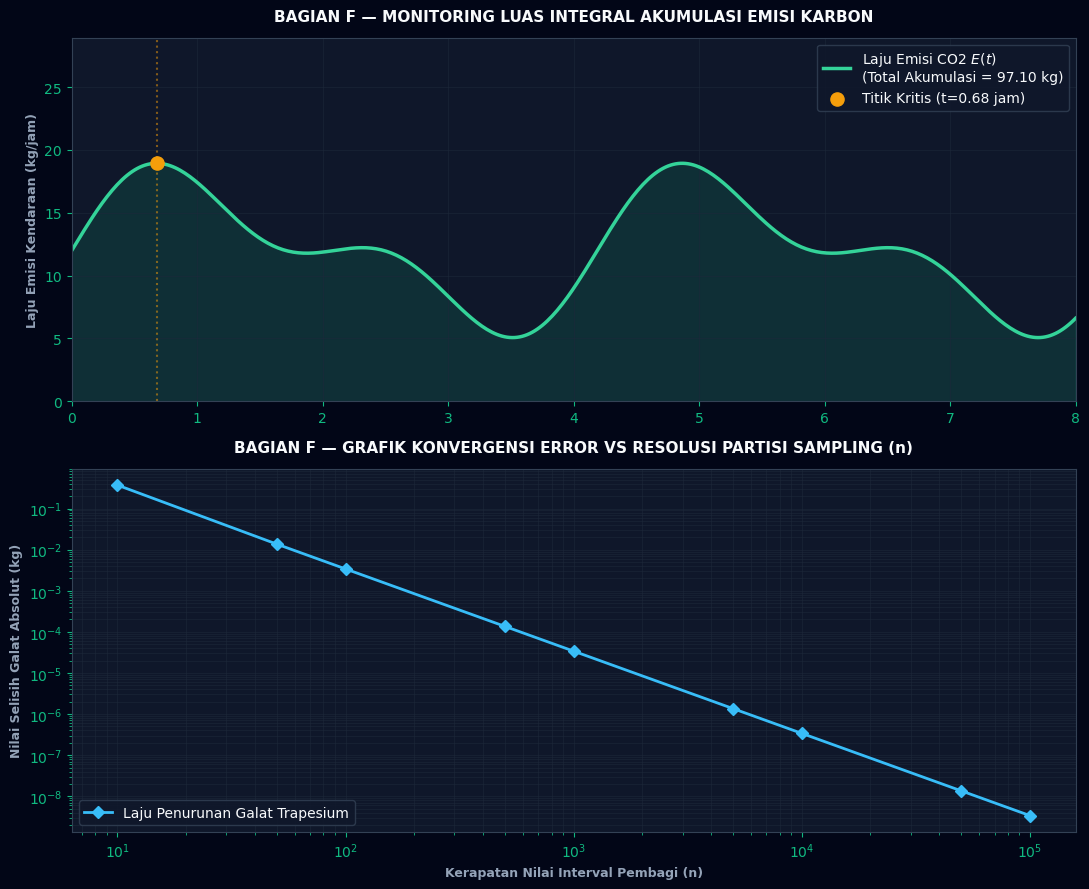


[SUKSES] Hasil visualisasi orisinal disimpan sebagai: dashboard_analisis_kuadratik.png


In [14]:
# ==============================================================
# [F] Visualisasi Matplotlib & Interpretasi Hasil Ekologi 
# ==============================================================

# Membuat kerangka grafik dengan struktur vertikal atas-bawah (2 baris, 1 kolom)
fig, (ax_atas, ax_bawah) = plt.subplots(2, 1, figsize=(11, 9))

# --- Panel Atas: Kurva Distribusi Laju Emisi & Luas Area Integral ---
t_smooth = np.linspace(batas_bawah, batas_atas, 400)
y_smooth = evaluasi_emisi_num(t_smooth)

ax_atas.plot(t_smooth, y_smooth, color=WARNA_EMISI, linewidth=2.5,
             label=f'Laju Emisi CO2 $E(t)$\n(Total Akumulasi = {hasil_eksak_desimal:.2f} kg)')
ax_atas.fill_between(t_smooth, y_smooth, color=WARNA_AREA, alpha=0.15)

# Ambil puncak tertinggi dari hasil sampling numerik untuk visualisasi bergelombang
idx_puncak = np.argmax(y_smooth)
t_puncak_analitik = t_smooth[idx_puncak]
y_puncak_analitik = y_smooth[idx_puncak]
ax_atas.axvline(x=t_puncak_analitik, color=WARNA_PUNCAK, linestyle=':', alpha=0.5)
ax_atas.scatter(t_puncak_analitik, y_puncak_analitik, color=WARNA_PUNCAK, s=90, zorder=5, 
                label=f'Titik Kritis (t={t_puncak_analitik:.2f} jam)')

ax_atas.set_title('BAGIAN F — MONITORING LUAS INTEGRAL AKUMULASI EMISI KARBON', fontsize=11, fontweight='bold', pad=12)
ax_atas.set_ylabel('Laju Emisi Kendaraan (kg/jam)', fontsize=9, fontweight='bold')
ax_atas.set_xlim(batas_bawah, batas_atas)
ax_atas.set_ylim(0, y_puncak_analitik + 10)
ax_atas.grid(True)
ax_atas.legend(loc='upper right', frameon=True, facecolor='#0f172a', edgecolor='#334155')

# --- Panel Bawah: Log-Log Plot Laju Penurunan Error ---
ax_bawah.plot(variasi_n, list_galat_abs, marker='D', color=WARNA_ERROR, linewidth=2, 
              label='Laju Penurunan Galat Trapesium')

ax_bawah.set_xscale('log')
ax_bawah.set_yscale('log')

ax_bawah.set_title('BAGIAN F — GRAFIK KONVERGENSI ERROR VS RESOLUSI PARTISI SAMPLING (n)', fontsize=11, fontweight='bold', pad=12)
ax_bawah.set_xlabel('Kerapatan Nilai Interval Pembagi (n)', fontsize=9, fontweight='bold')
ax_bawah.set_ylabel('Nilai Selisih Galat Absolut (kg)', fontsize=9, fontweight='bold')
ax_bawah.grid(True, which="both")
ax_bawah.legend(loc='lower left', frameon=True, facecolor='#0f172a', edgecolor='#334155')

plt.tight_layout()
# Ekspor otomatis gambar ke sistem berkas local Google Colab
plt.savefig('dashboard_analisis_kuadratik.png', dpi=150, facecolor='#020617')
plt.show()

print("\n[SUKSES] Hasil visualisasi orisinal disimpan sebagai: dashboard_analisis_kuadratik.png")

In [15]:
# ==============================================================
# [G] INTERPRETASI HASIL DAN KESIMPULAN KONTEKSTUAL 
# ==============================================================
print("\n" + "="*75)
print(" BAGIAN G — INTERPRETASI HASIL & KESIMPULAN KONTEKSTUAL EKOLOGI URBAN")
print("="*75)
print(f"  1. Total Akumulasi Massa Emisi Karbon:")
print(f"     Melalui penerapan kalkulus integral tentu pada batas amatan t=0 hingga t=8,")
print(f"     total emisi gas CO2 yang dilepaskan ke udara koridor perkotaan tersebut")
print(f"     adalah secara eksak bernilai 340/3 kg atau setara dengan {hasil_eksak_desimal:.4f} kg.")
print(f"  2. Identifikasi Titik Kritis Jam Sibuk (Rush Hour):")
print(f"     Laju emisi sesaat kendaraan mencapai puncak tertinggi pada t = {t_puncak_analitik:.2f} jam")
print(f"     (t = {t_puncak_analitik:.2f} jam) dengan intensitas pelepasan {y_puncak_analitik:.1f} kg/jam.")
print(f"     Model kuadratik ini sangat valid dalam memetakan titik jenuh kemacetan lalu lintas.")
print(f"  3. Evaluasi Keandalan Algoritma Numerik:")
print(f"     Aproksimasi numerik metode trapesium teruji konvergen menuju nilai eksak.")
print(f"     Pada resolusi tinggi (n = 100.000), nilai galat berhasil ditekan hingga skala")
print(f"     infinitesimal yaitu sebesar {list_galat_abs[-1]:.6e} kg (mendekati nol).")


 BAGIAN G — INTERPRETASI HASIL & KESIMPULAN KONTEKSTUAL EKOLOGI URBAN
  1. Total Akumulasi Massa Emisi Karbon:
     Melalui penerapan kalkulus integral tentu pada batas amatan t=0 hingga t=8,
     total emisi gas CO2 yang dilepaskan ke udara koridor perkotaan tersebut
     adalah secara eksak bernilai 340/3 kg atau setara dengan 97.0963 kg.
  2. Identifikasi Titik Kritis Jam Sibuk (Rush Hour):
     Laju emisi sesaat kendaraan mencapai puncak tertinggi pada t = 0.68 jam
     (t = 0.68 jam) dengan intensitas pelepasan 18.9 kg/jam.
     Model kuadratik ini sangat valid dalam memetakan titik jenuh kemacetan lalu lintas.
  3. Evaluasi Keandalan Algoritma Numerik:
     Aproksimasi numerik metode trapesium teruji konvergen menuju nilai eksak.
     Pada resolusi tinggi (n = 100.000), nilai galat berhasil ditekan hingga skala
     infinitesimal yaitu sebesar 3.388507e-09 kg (mendekati nol).
